In [38]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('xrf_summary.csv')
df.head()

# aluminium is a light element so isnt possible to measure with xrf?

,Sample Location,Grain Size,Ag Mean,Ag Std,As Mean,As Std,Au Mean,Au Std,Cd Mean,Cd Std,...,V Std,Y Mean,Y Std,Zn Mean,Zn Std,Zr Mean,Zr Std,Final pH,Start pH (field),Start pH (lab)
0,Covica_S3,0.63mm,19.531900,NaN,11.517200,NaN,NaN,NaN,NaN,NaN,...,NaN,1.3748,NaN,53.255300,NaN,8.36820,NaN,6.12,2.12,2.24
1,Covica_S3,1.18mm,24.075967,4.871751,23.633100,0.065696,5.2439,NaN,NaN,NaN,...,41.742693,NaN,NaN,76.315133,8.508651,NaN,NaN,6.08,2.12,2.32
2,Covica_S3,1.8mm,29.765167,12.890839,20.153033,2.284950,NaN,NaN,15.639,NaN,...,NaN,1.3881,NaN,78.343300,17.500271,NaN,NaN,5.58,2.12,2.32
3,Covica_S4,0.63mm,29.779200,3.244311,13.199100,3.493437,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,36.270067,2.648842,11.83195,3.63163,6.84,2.37,2.61
4,Covica_S4,1.18mm,28.811700,3.517438,10.064700,3.200487,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,47.775600,17.309713,5.18550,NaN,6.78,2.37,2.61


In [40]:

site_order = ["LG_Spring", "LG_Lake", "Covica_S3", "Covica_S4"]
site_labels = {
    "LG_Spring": "LG Spring",
    "LG_Lake": "LG Lake",
    "Covica_S3": "Covica S3",
    "Covica_S4": "Covica S4",
}

grain_sizes = ["0.63mm", "1.18mm", "1.8mm"]


grainsize_colours = {
    "0.63mm": "#d049d0",   
    "1.18mm": "#2c2c9e",   
    "1.8mm":  "#9b91dd", 
}

grainsize_markers = {
    "0.63mm": "o",
    "1.18mm": "s",
    "1.8mm":  "^",
}


# order the dataframe by sample location and grain size
df["Sample Location"] = pd.Categorical(df["Sample Location"], categories=site_order, ordered=True)
df["Grain Size"] = pd.Categorical(df["Grain Size"], categories=grain_sizes, ordered=True)
df = df.sort_values(["Sample Location", "Grain Size"]).reset_index(drop=True)


def get_mean_std(df, element):
    mean_col, std_col = f"{element} Mean", f"{element} Std"
    return mean_col, std_col


In [41]:
# Line plots of each element conc. vs site per grain size with stdev error bars where available
# if only 1 measurment >LOD then no stdev and no error bar plotted

def plot_element(df, element, show_legend=True, ax=None):
    """Plot one element's concentration vs site, one line per grain size."""
    mean_col, std_col = get_mean_std(df, element)


    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(6, 4.5))

    x_positions = np.arange(len(site_order))

    for gs in grain_sizes:
        sub = df[df["Grain Size"] == gs].set_index("Sample Location")
        sub = sub.reindex(site_order)
        y = sub[mean_col].values
        yerr = sub[std_col].values

        valid = ~np.isnan(y)
        yerr_plot = np.where(np.isnan(yerr), 0, yerr)

        ax.errorbar(
            x_positions[valid], y[valid], yerr=yerr_plot[valid],
            marker=grainsize_markers[gs], color=grainsize_colours[gs],
            label=gs, capsize=3, linewidth=1.8, markersize=6,
            elinewidth=1, ecolor=grainsize_colours[gs], alpha=0.9,
        )

    ax.set_xticks(x_positions)
    ax.set_xticklabels([site_labels[s] for s in site_order], rotation=15, ha="right")
    ax.set_ylabel(f"{element} concentration (ppm)")
    ax.set_title(element)
    ax.grid(alpha=0.3, linewidth=0.6)
    if show_legend:
        ax.legend(title="Grain size", fontsize=8, title_fontsize=8)

    if standalone:
        ax.set_xlabel("Sample location")
        fig.tight_layout()
        return fig
    return None


def multiple_plots(elements, filename="elements_panel.png"):
    n = len(elements)
    ncols = 4
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.6 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, element in enumerate(elements):
        plot_element(df, element, ax=axes[i], show_legend=(i == 0))

    for j in range(n, len(axes)):
        axes[j].axis("off")

    
    fig.tight_layout()
    fig.savefig(filename, dpi=200, bbox_inches="tight")
    plt.close(fig)
    return fig


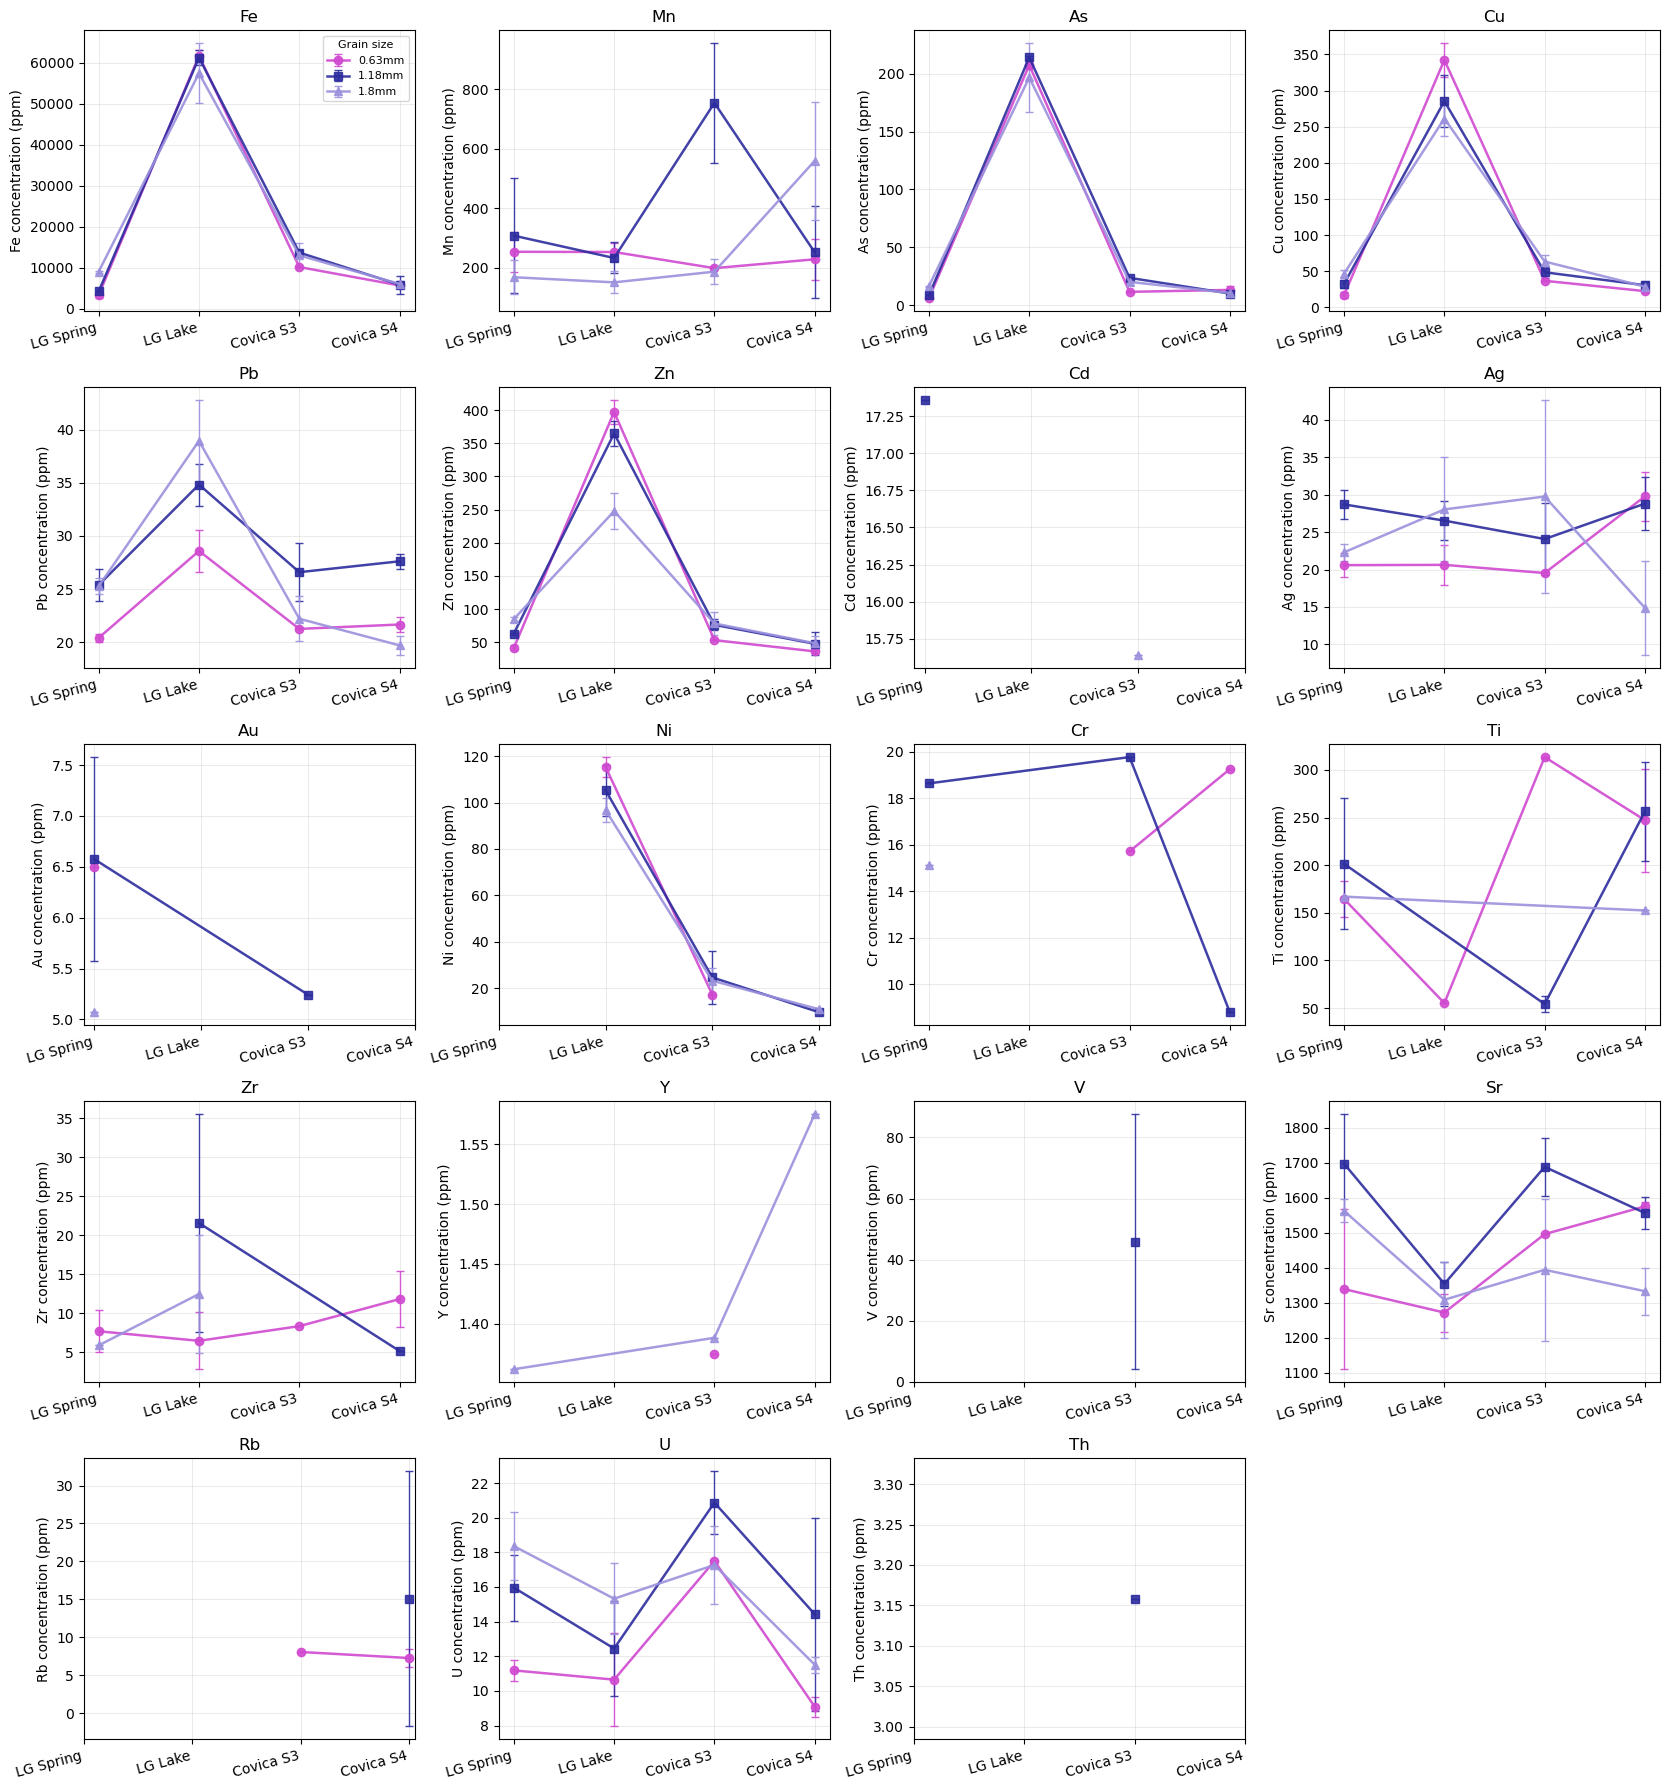

In [42]:
elements = ["Fe", "Mn", "As", "Cu", "Pb", "Zn", "Cd", "Ag", "Au", "Ni", "Cr", "Ti", "Zr", "Y", "V", "Sr", "Rb", "U", "Th"]
multiple_plots(elements, filename="all_elements_panel.png")

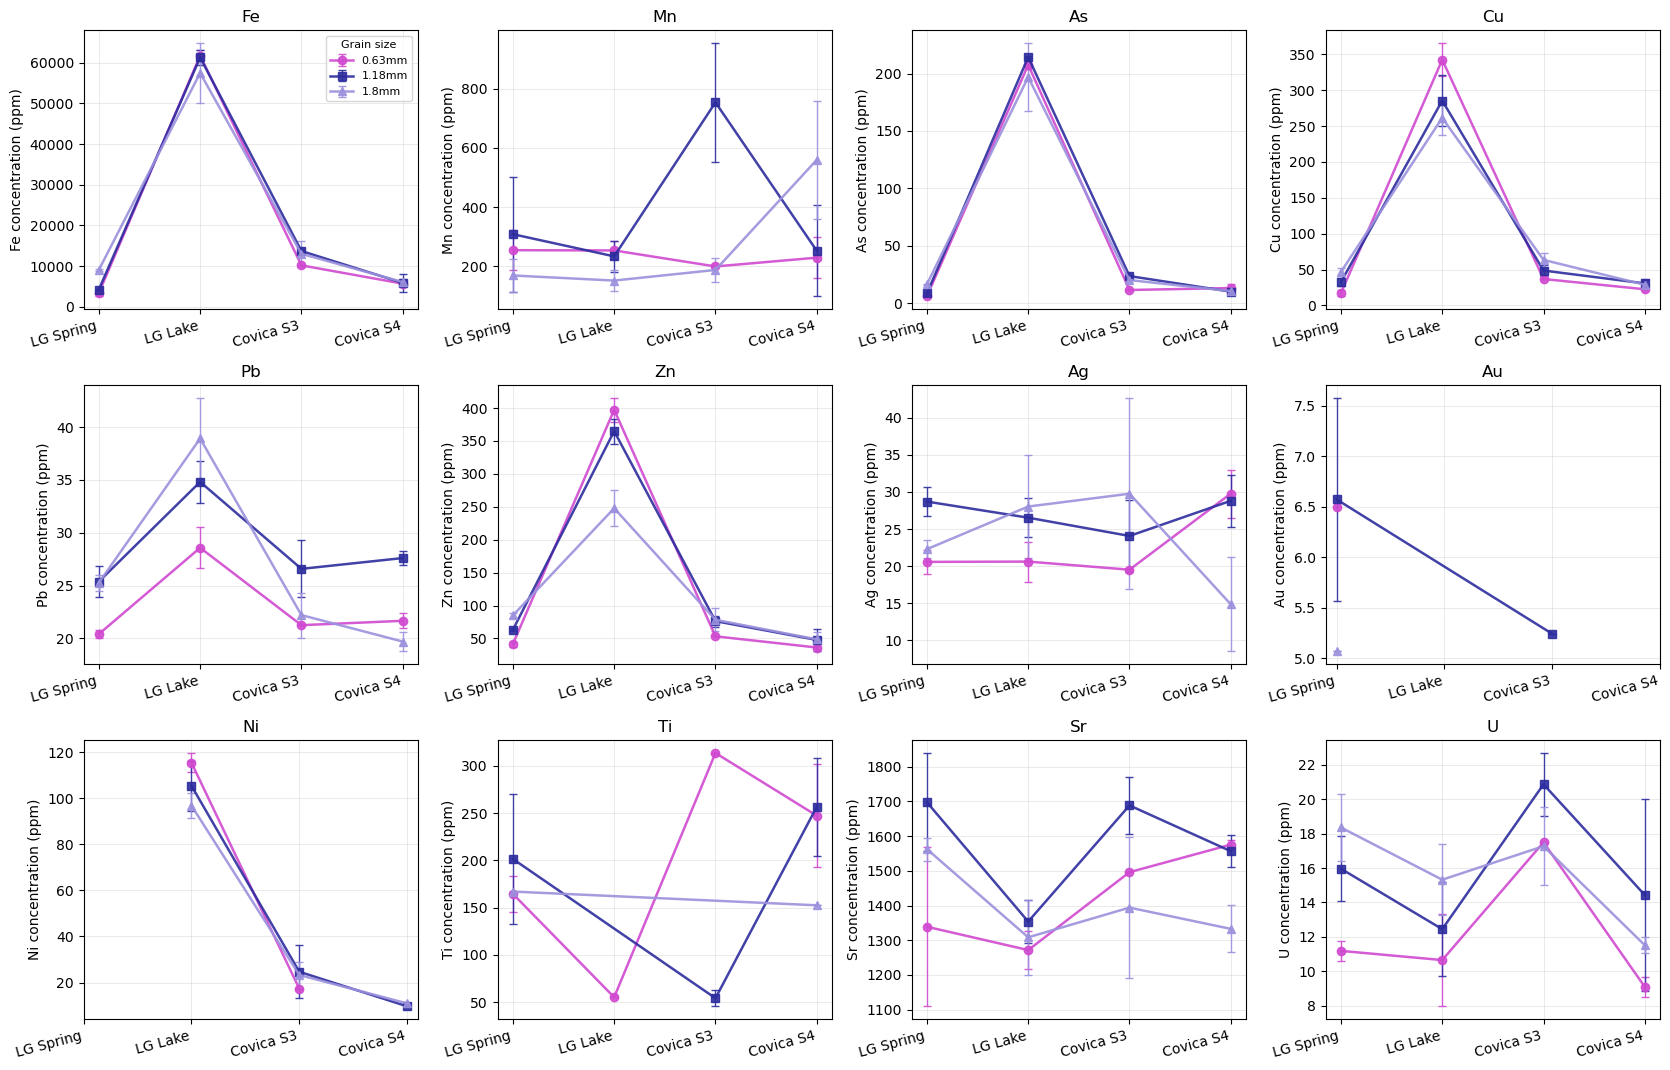

In [43]:
elements_subset = ["Fe", "Mn", "As", "Cu", "Pb", "Zn", "Ag", "Au", "Ni", "Ti", "Sr", "U"]
multiple_plots(elements_subset, filename="subset_elements_panel.png")

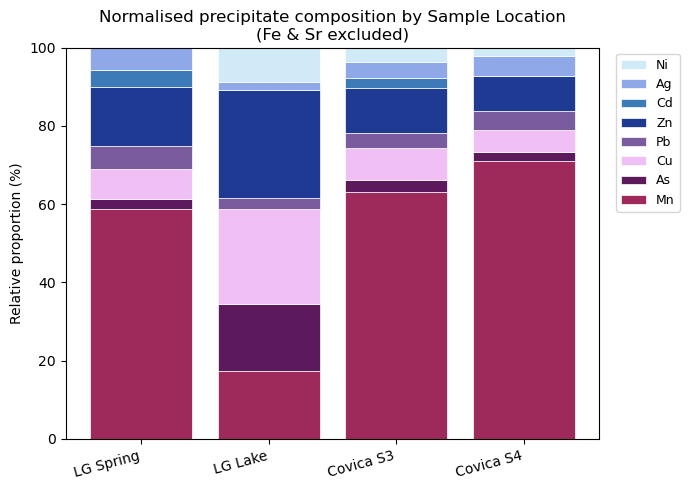

In [84]:
# Stacked, normalised (to 100%) composition bar chart - shows the RELATIVE
# elemental "recipe" of the precipitate at each site, averaged across grain sizes.

# NaN handling: missing element values are treated as a zero contribution for
# that site (not dropped), so the remaining elements still sum to 100%.

stacked_colours = [
    "#9E2A5C",     
    # "#B08DD6",
    "#5C1A5C",
    "#EFBFF5",
    "#7A5C9E",
    "#1F3A93",  
    "#3D7AB8",
    "#8FA8E8",   
    "#D0EBF7",
]

def site_means(df, elements):
    """Average each element's mean across the 3 grain sizes, per site."""
    rows = []
    for site in site_order:
        sub = df[df["Sample Location"] == site]
        row = {"Sample Location": site}
        for e in elements:
            col = f"{e} Mean"
            row[e] = sub[col].mean(skipna=True) if col in df.columns else np.nan
        rows.append(row)
    return pd.DataFrame(rows).set_index("Sample Location")


def stacked_composition_plot(df, elements, title, filename, exclude=None):
    """Plot a 100%-normalised stacked bar chart of element composition by site.
    Pass exclude=['Fe'] to drop an element (e.g. Fe) and re-normalise the rest because Fe dominates otherwise."""
    exclude = exclude or []
    elements_to_plot = [e for e in elements if e not in exclude]

    means_df = site_means(df, elements_to_plot)
    data = means_df.fillna(0)              #missing values contribute 0 to the total stack
    row_sums = data.sum(axis=1)
    norm = data.div(row_sums, axis=0) * 100  #normalise each site's row to 100%

    fig, ax = plt.subplots(figsize=(7, 5))
    bottom = np.zeros(len(norm))
    x_pos = np.arange(len(norm))

    for i, elem in enumerate(elements_to_plot):
        vals = norm[elem].values
        ax.bar(x_pos, vals, bottom=bottom, label=elem,
               color=stacked_colours[i % len(stacked_colours)],
               edgecolor="white", linewidth=0.5)
        bottom += vals

    ax.set_xticks(x_pos)
    ax.set_xticklabels([site_labels[s] for s in norm.index], rotation=15, ha="right")
    ax.set_ylabel("Relative proportion (%)")
    ax.set_ylim(0, 100)
    ax.set_title(title)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
    fig.tight_layout()

    fig.savefig(filename, dpi=200, bbox_inches="tight")
    plt.close(fig)
    return fig
amd_elements = ["Fe", "Mn", "As", "Cu", "Pb", "Zn", "Cd", "Ag", "Ni", "Sr"]

# version 1: Fe included - shows the true picture, but Fe will dominate visually
stacked_composition_plot(
    df, amd_elements,
    title="Normalised precipitate composition by Sample Location\n(Fe included)",
    filename="stacked_composition_with_Fe.png",
)

# version 2: Fe excluded and re-normalised - reveals the trace-metal proportions
stacked_composition_plot(
    df, amd_elements,
    title="Normalised precipitate composition by Sample Location\n(Fe & Sr excluded)",
    filename="stacked_composition_no_Fe.png",
    exclude=["Fe", "Sr"],
)














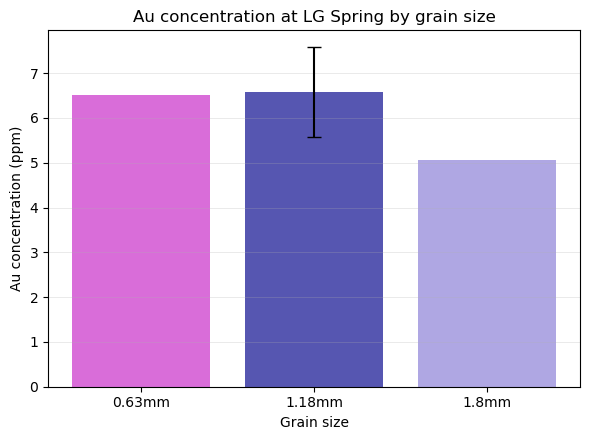

In [44]:
# bar plot of Au at LG_Spring per grain size
au_spring = df[df["Sample Location"] == "LG_Spring"].set_index("Grain Size").reindex(grain_sizes)
au_means = au_spring["Au Mean"].values
au_stds = au_spring["Au Std"].values
x_pos = np.arange(len(grain_sizes))
plt.figure(figsize=(6, 4.5))
plt.bar(x_pos, au_means, yerr=au_stds, capsize=5, color=[grainsize_colours[gs] for gs in grain_sizes], alpha=0.8)
plt.xticks(x_pos, grain_sizes)
plt.xlabel("Grain size")
plt.ylabel("Au concentration (ppm)")
plt.title("Au concentration at LG Spring by grain size")
plt.grid(alpha=0.3, axis="y", linewidth=0.6)
plt.tight_layout()


In [45]:
all_elements= ["Ag", "As", "Au", "Cd", "Cr", "Cu", "Fe", "Mn", "Ni", "Pb", "Rb", "Sr", "Th", "Ti", "U", "V", "Y", "Zn", "Zr"]

def correlation_matrix(df, elements, min_valid=6):
    """Build a Pearson correlation matrix across elements, using each
    site/grain-size row as one observation""" 
    mean_cols = {e: f"{e} Mean" for e in elements if f"{e} Mean" in df.columns}
    sub = df[list(mean_cols.values())].copy()
    sub.columns = list(mean_cols.keys())

    enough_data = sub.columns[sub.notna().sum() >= min_valid]
    dropped = [e for e in sub.columns if e not in enough_data]
    if dropped:
        print(f"Dropped (fewer than {min_valid} non-missing values): {dropped}")

    sub = sub[enough_data]
    corr = sub.corr(method="pearson") 
    return corr



def top_correlations(corr, n=15):
    pairs = []
    cols = corr.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            pairs.append((cols[i], cols[j], corr.iloc[i, j]))
    pairs_df = pd.DataFrame(pairs, columns=["Element A", "Element B", "r"])
    pairs_df["abs_r"] = pairs_df["r"].abs()
    return pairs_df.sort_values("abs_r", ascending=False).drop(columns="abs_r").head(n).reset_index(drop=True)

In [46]:
corr = correlation_matrix(df, all_elements)

top_correlations(corr)


Dropped (fewer than 6 non-missing values): ['Au', 'Cd', 'Rb', 'Th', 'V', 'Y']


,Element A,Element B,r
0,Fe,Ni,0.997618
1,Cu,Ni,0.996366
2,As,Fe,0.996059
3,As,Ni,0.993592
4,Cu,Fe,0.990846
5,Cr,Ni,0.990257
6,As,Cu,0.988482
7,Cu,Zn,0.986935
8,Ni,Zn,0.981295
9,Fe,Zn,0.971857


In [47]:
# pearson correlation coefficients are not representative of true correlation but driven by the extreme values at LG Lake creating two data clusters
site_colours = {
    "LG_Spring": "#9B30C9",
    "LG_Lake":   "#1F3A93",
    "Covica_S3": "#9E2A5C",
    "Covica_S4": "#3D7AB8",
}

def fe_vs_elements_grid(df, elements, filename="fe_vs_elements.png"):
    """2x3 grid of Fe vs each element in `elements`, coloured by site."""
    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    axes = axes.reshape(-1)

    for i, elem in enumerate(elements):
        ax = axes[i]
        for site in site_order:
            sub = df[df["Sample Location"] == site]
            ax.scatter(
                sub["Fe Mean"], sub[f"{elem} Mean"],
                color=site_colours[site], s=40, alpha=0.85,
                label=site_labels[site] if i == 0 else None,
            )
        ax.set_xlabel("Fe concentration (ppm)")
        ax.set_ylabel(f"{elem} concentration (ppm)")
        ax.set_title(f"Fe vs {elem}")
        ax.grid(alpha=0.3, linewidth=0.6)

    # hide unused panels
    for j in range(len(elements), len(axes)):
        axes[j].axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.0, 1.02), fontsize=9, title="Site")

    fig.suptitle("Fe vs As, Cu, Ni, Zn & Pb concentrations", fontsize=13, y=1.02)
    fig.tight_layout()
    fig.savefig(filename, dpi=200, bbox_inches="tight")
    plt.close(fig)
    return fig

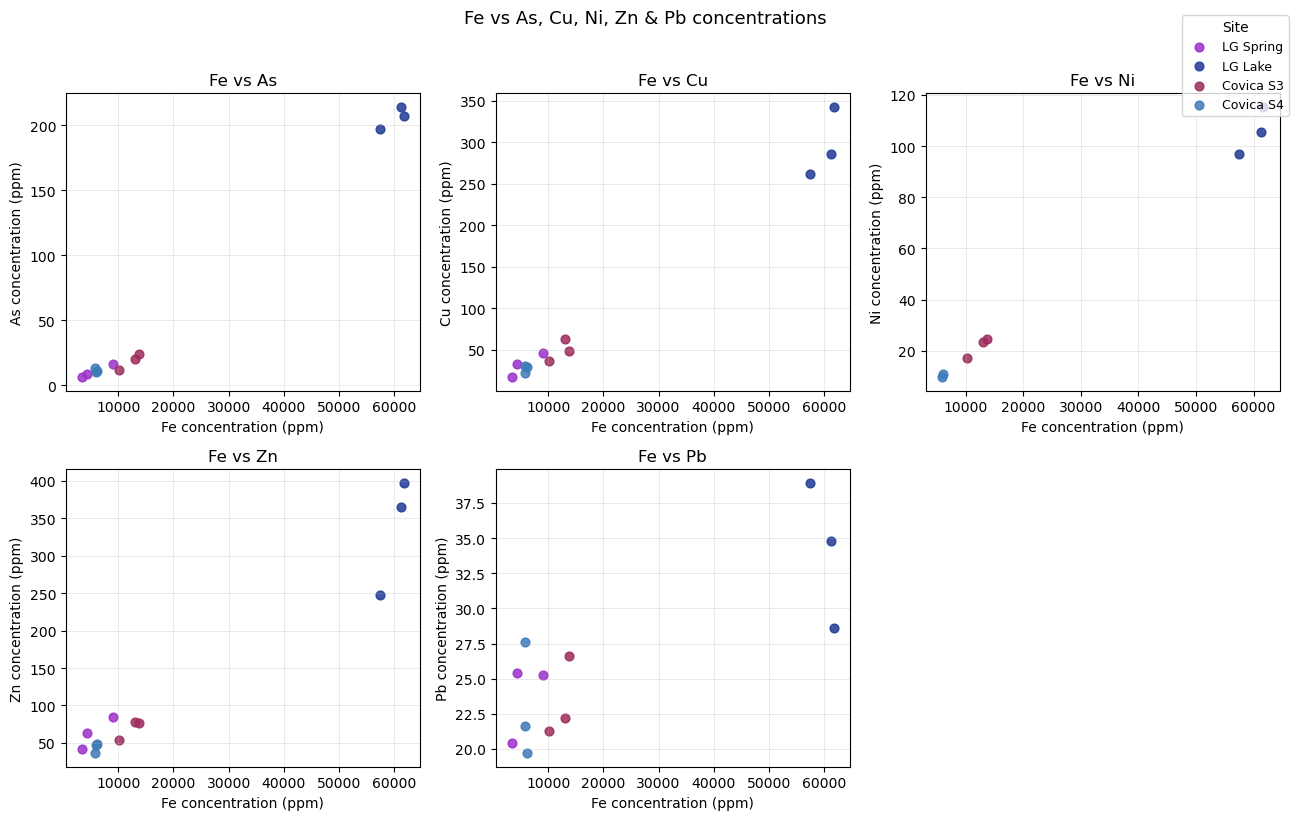

In [48]:
fe_vs_elements_grid(df, ["As", "Cu", "Ni", "Zn", "Pb"])

In [49]:


# Plot 1: Final pH vs site, by grain size

def plot_final_ph_by_site(df, filename="final_pH_by_site.png"):
    fig, ax = plt.subplots(figsize=(6, 4.5))
    x_positions = np.arange(len(site_order))

    for gs in grain_sizes:
        sub = df[df["Grain Size"] == gs].set_index("Sample Location").reindex(site_order)
        y = sub["Final pH"].values
        valid = ~np.isnan(y)
        ax.plot(
            x_positions[valid], y[valid],
            marker=grainsize_markers[gs], color=grainsize_colours[gs],
            label=gs, linewidth=1.8, markersize=7,
        )

    ax.set_xticks(x_positions)
    ax.set_xticklabels([site_labels[s] for s in site_order], rotation=15, ha="right")
    ax.set_ylabel("Final pH")
    ax.set_xlabel("Sample location")
    ax.set_title("Final pH reached, by site and grain size")
    ax.grid(alpha=0.3, linewidth=0.6)
    ax.legend(title="Grain size", fontsize=8, title_fontsize=8)
    fig.tight_layout()
    fig.savefig(filename, dpi=200, bbox_inches="tight")
    plt.close(fig)
    return fig


# element concentration vs Final pH 


def elements_vs_ph_grid(df, elements, colour_by="site", filename="elements_vs_pH.png"):
    """Grid of element concentration vs Final pH, one panel per element.
    colour_by: 'site' or 'grainsize' - which grouping to colour points by."""
    n = len(elements)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.3*ncols, 3.8*nrows))
    axes = np.array(axes).reshape(-1)

    groups = site_order if colour_by == "site" else grain_sizes
    colours = site_colours if colour_by == "site" else grainsize_colours
    group_col = "Sample Location" if colour_by == "site" else "Grain Size"
    group_labels = site_labels if colour_by == "site" else {g: g for g in grain_sizes}

    for i, elem in enumerate(elements):
        ax = axes[i]
        for g in groups:
            sub = df[df[group_col] == g]
            kwargs = {"marker": grainsize_markers[g]} if colour_by == "grainsize" else {}
            ax.scatter(
                sub["Final pH"], sub[f"{elem} Mean"],
                color=colours[g], s=40, alpha=0.85,
                label=group_labels[g] if i == 0 else None, **kwargs,
            )

        r = df["Final pH"].corr(df[f"{elem} Mean"])
        ax.text(
            0.05, 0.95, f"r = {r:.2f}", transform=ax.transAxes,
            ha="left", va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="grey", alpha=0.8),
        )
        ax.set_xlabel("Final pH")
        ax.set_ylabel(f"{elem} concentration (ppm)")
        ax.set_title(elem)
        ax.grid(alpha=0.3, linewidth=0.6)

    for j in range(n, len(axes)):
        axes[j].axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.0, 1.02), fontsize=9,
               title="Site" if colour_by == "site" else "Grain size")
    fig.suptitle("Element concentration vs Final pH", fontsize=13, y=1.02)
    fig.tight_layout()
    fig.savefig(filename, dpi=200, bbox_inches="tight")
    plt.close(fig)
    return fig




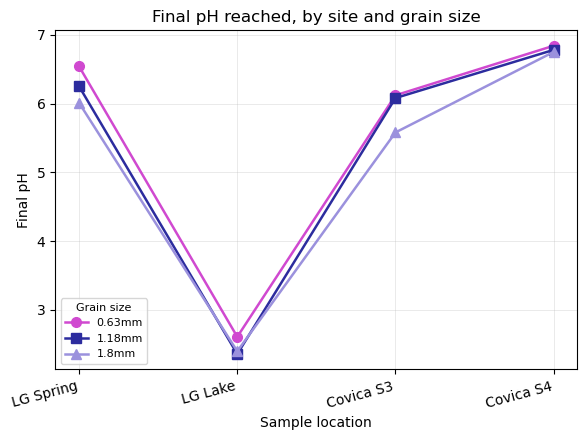

In [50]:
plot_final_ph_by_site(df)



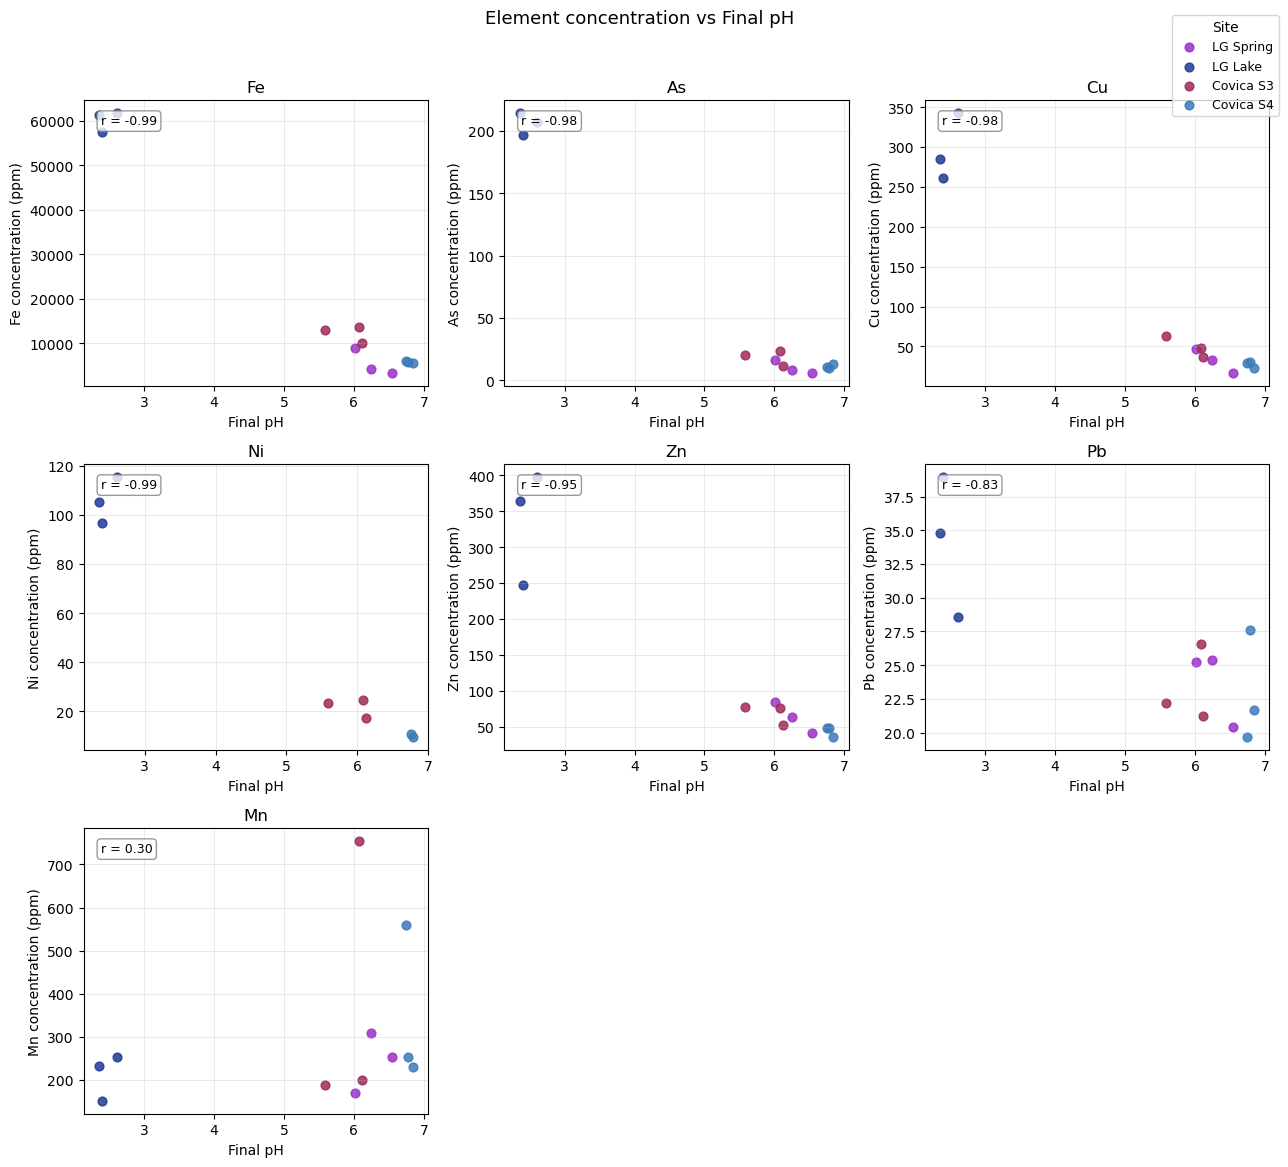

In [85]:
elements_vs_ph_grid(df, ["Fe", "As", "Cu", "Ni", "Zn", "Pb", "Mn"], colour_by="site")

In [ ]:


trivalent_elements = ["Fe", "Cr"]
divalent_elements = ["Mn", "Cu", "Zn", "Pb", "Ni", "Cd"]


def plot_concentration_vs_ph_by_valence(df, trivalent, divalent, filename="concentration_vs_pH_by_valence.png"):
    """ raw concentration vs Final pH."""
    ncols = max(len(trivalent), 3)
    n_trivalent_rows = int(np.ceil(len(trivalent) / ncols))
    n_divalent_rows = int(np.ceil(len(divalent) / ncols))
    nrows = n_trivalent_rows + n_divalent_rows

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 3.5*nrows))
    axes = np.array(axes).reshape(nrows, ncols)

    def fill_row_block(elements, row_start, label_prefix):
        for idx, elem in enumerate(elements):
            r, c = divmod(idx, ncols)
            ax = axes[row_start + r, c]
            col = f"{elem} Mean"
            for site in site_order:
                sub = df[df["Sample Location"] == site]
                ax.scatter(sub["Final pH"], sub[col], color=site_colours[site], s=40, alpha=0.85,
                           label=site_labels[site] if (row_start == 0 and idx == 0) else None)
            ax.set_title(f"{label_prefix}: {elem}", fontsize=10)
            ax.set_xlabel("Final pH")
            ax.set_ylabel(f"{elem} (ppm)")
            ax.grid(alpha=0.3, linewidth=0.6)
        used = len(elements)
        total_slots = int(np.ceil(used/ncols)) * ncols
        for idx in range(used, total_slots):
            r, c = divmod(idx, ncols)
            axes[row_start + r, c].axis("off")

    fill_row_block(trivalent, 0, "Trivalent")
    fill_row_block(divalent, n_trivalent_rows, "Divalent")

    fig.tight_layout()


    handles, labels = axes[0,0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.0, 1.02), fontsize=9, title="Site")
    fig.suptitle("Concentration vs Final pH, grouped by valence (top: trivalent, bottom: divalent)", fontsize=13, y=1.04)
    fig.savefig(filename, dpi=200, bbox_inches="tight")
    plt.close(fig)
    return fig

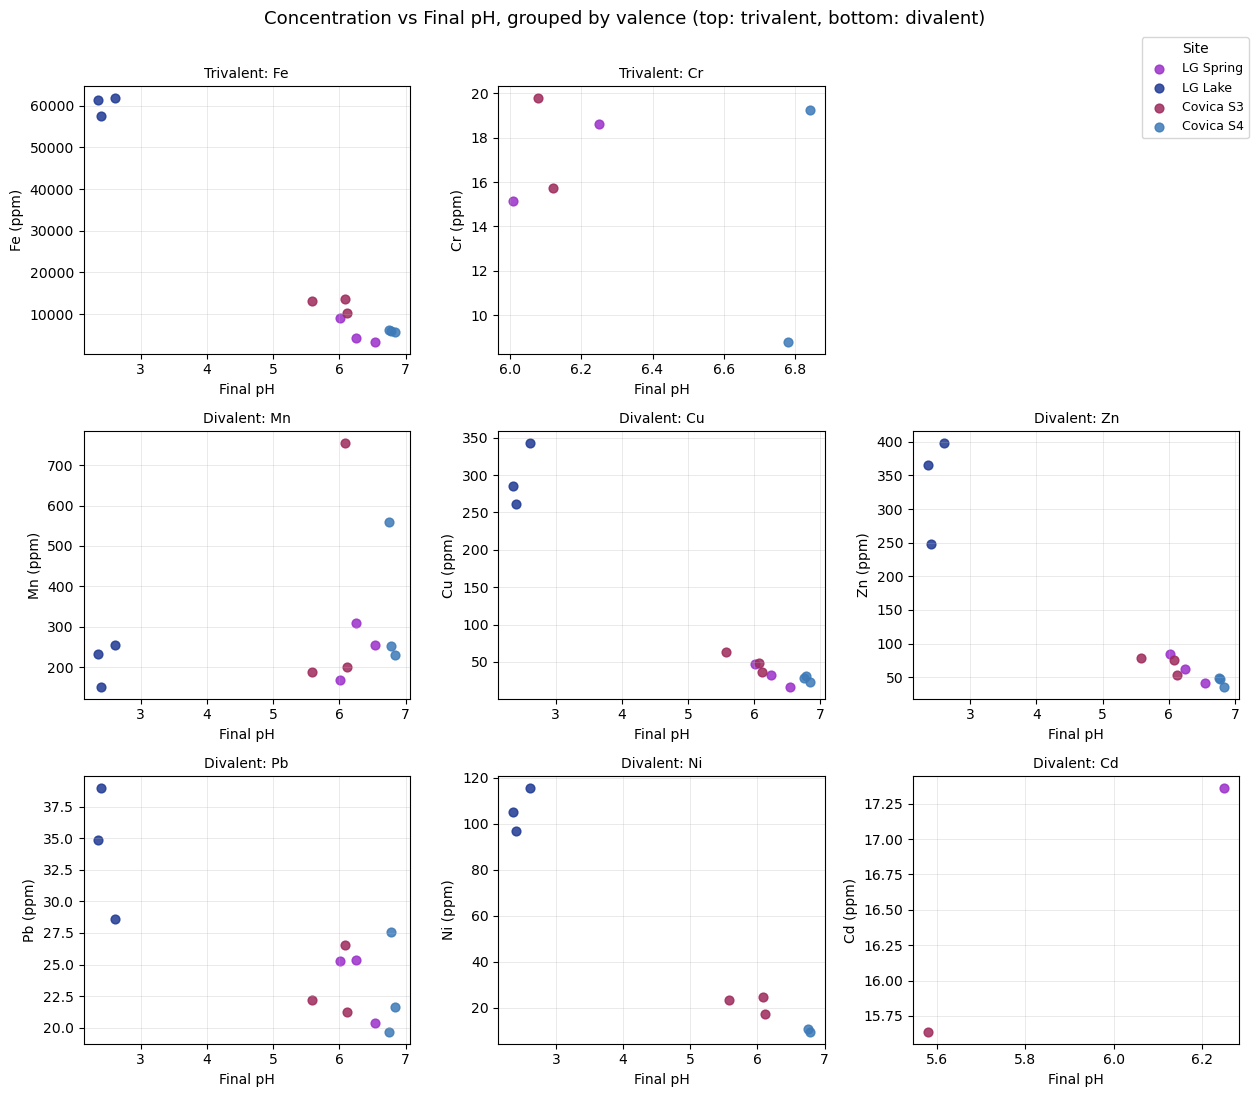

In [58]:
plot_concentration_vs_ph_by_valence(df, trivalent_elements, divalent_elements)

In [86]:

# Delta pH = Final - Start is a measure of NEUTRALISATION PERFORMANCE,


df["Delta pH"] = df["Final pH"] - df["Start pH (lab)"]


# --- Plot 1: Delta pH by site and grain size ---
def plot_delta_ph_by_site(df, filename="delta_pH_by_site.png"):
    """Delta pH (Final - Start) vs site, one line per grain size."""
    fig, ax = plt.subplots(figsize=(6, 4.5))
    x_positions = np.arange(len(site_order))

    for gs in grain_sizes:
        sub = df[df["Grain Size"] == gs].set_index("Sample Location").reindex(site_order)
        y = sub["Delta pH"].values
        valid = ~np.isnan(y)
        ax.plot(
            x_positions[valid], y[valid],
            marker=grainsize_markers[gs], color=grainsize_colours[gs],
            label=gs, linewidth=1.8, markersize=7,
        )

    ax.set_xticks(x_positions)
    ax.set_xticklabels([site_labels[s] for s in site_order], rotation=15, ha="right")
    ax.set_ylabel("\u0394pH (Final \u2212 Start)")
    ax.set_xlabel("Sample location")
    ax.set_title("Neutralisation achieved (\u0394pH)")
    ax.grid(alpha=0.3, linewidth=0.6)
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.legend(title="Grain size", fontsize=8, title_fontsize=8)
    fig.tight_layout()
    fig.savefig(filename, dpi=200, bbox_inches="tight")
    plt.close(fig)
    return fig





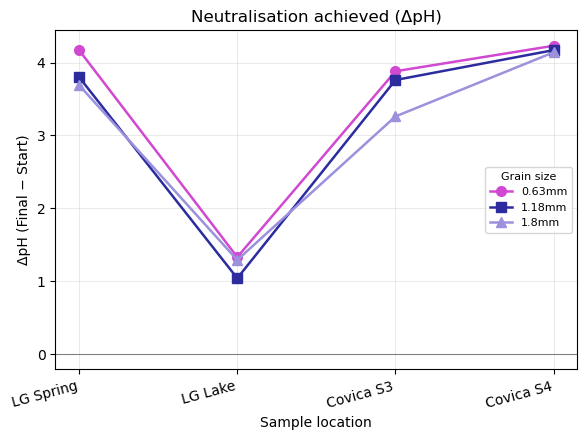

In [87]:
plot_delta_ph_by_site(df)

